# Lab №2

## Steps

### 0. Import necessary libraries

In [15]:
from math import pi
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt
import spatialmath.base as sb

### 1. Import the UR5 model

In [16]:
robot = rtb.models.DH.UR5()
print(robot)

DHRobot: UR5 (by Universal Robotics), 6 joints (RRRRRR), dynamics, standard DH parameters
┌─────┬─────────┬─────────┬────────┐
│ θⱼ  │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├─────┼─────────┼─────────┼────────┤
│  q1 │ 0.08946 │       0 │  90.0° │
│  q2 │       0 │  -0.425 │   0.0° │
│  q3 │       0 │ -0.3922 │   0.0° │
│  q4 │  0.1091 │       0 │  90.0° │
│  q5 │ 0.09465 │       0 │ -90.0° │
│  q6 │  0.0823 │       0 │   0.0° │
└─────┴─────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬───────┬─────┬─────┬─────┬──────┬─────┐
│ name │ q0    │ q1  │ q2  │ q3  │ q4   │ q5  │
├──────┼───────┼─────┼─────┼─────┼──────┼─────┤
│   qr │  180° │  0° │  0° │  0° │  90° │  0° │
│   qz │  0°   │  0° │  0° │  0° │  0°  │  0° │
└──────┴───────┴─────┴─────┴─────┴──────┴─────┘



### 1.5 Fill in the parameters of the robot model 

In [17]:
# 1. Mass of the links
robot.links[0].m = 3.7
robot.links[1].m = 8.393
robot.links[2].m = 2.275
robot.links[3].m = 1.219
robot.links[4].m = 1.219
robot.links[5].m = 0.1879

# 2. Center of mass of each link
robot.links[0].r = [0.0, 0.0, 0.0]
robot.links[1].r = [-0.2125, 0.0, 0.136]
robot.links[2].r = [-0.196125, 0.0, 0.0165]
robot.links[3].r = [0.0, 0.0, 0.0]
robot.links[4].r = [0.0, 0.0, 0.0]
robot.links[5].r = [0.0, 0.0, -0.01525]

# 3. Inertia tensor of each link [Lxx, Lyy, Lzz, Lxy, Lyz, Lxz]
robot.links[0].I = [0.014972352344389999, 0.014972352344389999, 0.01040625, 0.0, 0.0, 0.0]
robot.links[1].I = [0.1338857818623325, 0.1338857818623325, 0.0151074, 0.0, 0.0, 0.0]
robot.links[2].I = [0.03121679102890359, 0.03121679102890359, 0.004095, 0.0, 0.0, 0.0]
robot.links[3].I = [0.0020138887777775, 0.0020138887777775, 0.0021942, 0.0, 0.0, 0.0]
robot.links[4].I = [0.0018310388509175, 0.0018310388509175, 0.0021942, 0.0, 0.0, 0.0]
robot.links[5].I = [8.062472608343e-05, 8.062472608343e-05, 0.0001321171875, 0.0, 0.0, 0.0]

# 4. Moment of inertia of the drive
for i in range(6): robot.links[i].Jm = 0.0

# 5. Coefficient of viscous friction
for i in range(6): robot.links[i].B = 0.0

# 6. Coefficient of Coulomb friction
for i in range(6): robot.links[i].Tc = [0.0, 0.0]

# 7. Gear ratio
for i in range(6): robot.links[i].G = 1

# 8. Restrictions on the generalized coordinates
robot.links[0].qlim = [-2*pi, 2*pi]
robot.links[1].qlim = [-2*pi, 2*pi]
robot.links[2].qlim = [-pi, pi]
robot.links[3].qlim = [-2*pi, 2*pi]
robot.links[4].qlim = [-2*pi, 2*pi]
robot.links[5].qlim = [-2*pi, 2*pi]

### 2. Set the initial position of the robot and plot it

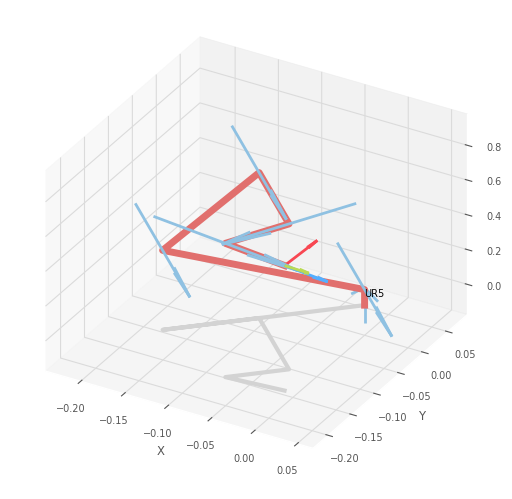

<Figure size 640x480 with 0 Axes>

In [18]:
q_start = [pi/4, -pi/3, -pi/4, pi/3, -pi/3, pi/4]
robot.plot(q_start)
plt.show()

### 3. Solve the forward kinematics task

In [19]:
T_start = robot.fkine(q_start)
print(T_start)

   0.09732   0.6098    0.7866    0.01612   
   0.9633   -0.2562    0.07946  -0.1964    
   0.25      0.75     -0.6124    0.7191    
   0         0         0         1         



### 4. Plot the workspace of the manipulator

Initialize variables

In [ ]:
n = 20  # Number of points per axis
i = 0  # Counter
move = [np.linspace(robot.links[i].qlim[0], robot.links[i].qlim[1], n) for i in range(3)]  # Record limits for the first three links
pose = np.zeros([3,n**3])  # Create empty array to store data

Calculate the workspace

In [ ]:
# Iterate through each point
for q1 in move[0]:
    for q2 in move[1]:
        for q3 in move[2]:
            Tt = robot.fkine([q1,q2,q3,0,0,0])  # Solve FP, changing only first 3 coordinate
            for j in range(3):
                pose[j][i] = Tt.t[j]  # Save the point
            i += 1

Plot the workspace

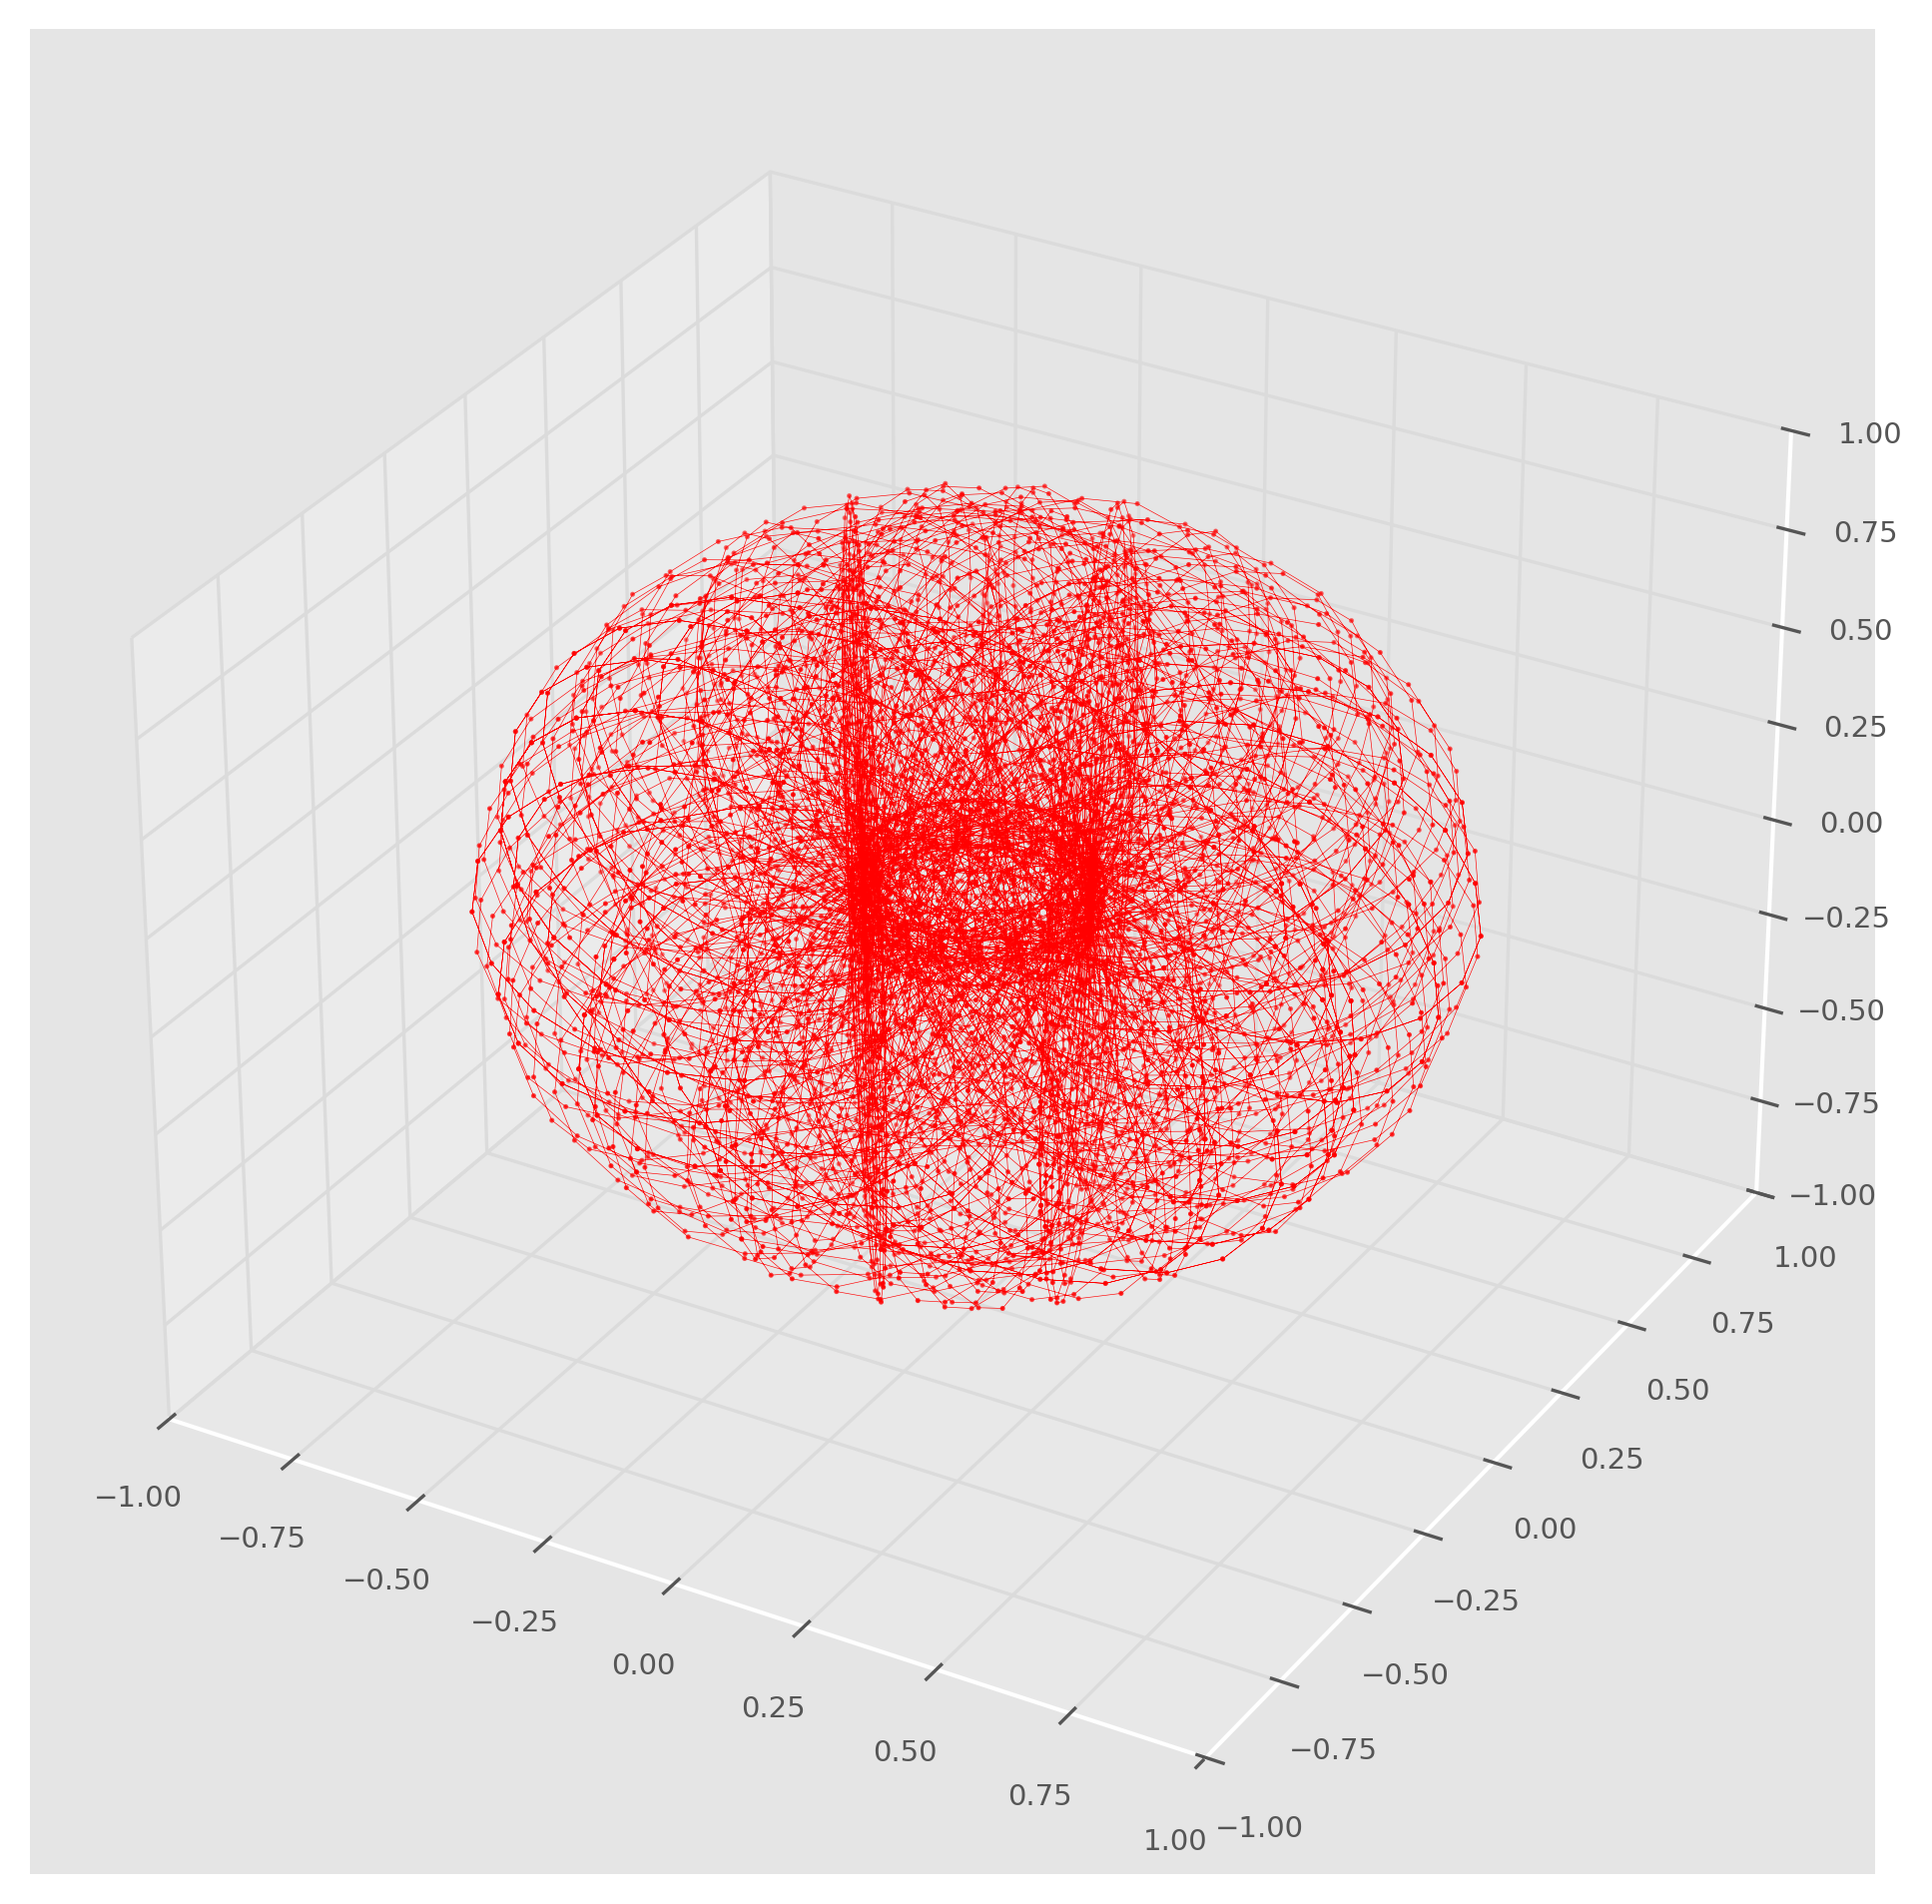

In [22]:
plt.figure(figsize=(8,8), dpi=300)
ax = plt.axes(projection="3d")
ax.plot3D(pose[0], pose[1], pose[2], color='red', linewidth=0.15)
ax.scatter3D(pose[0], pose[1], pose[2], s=0.5, color='red')
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(-1,1)
plt.show()

### 5. Select the end point and solve the inverse kinematics

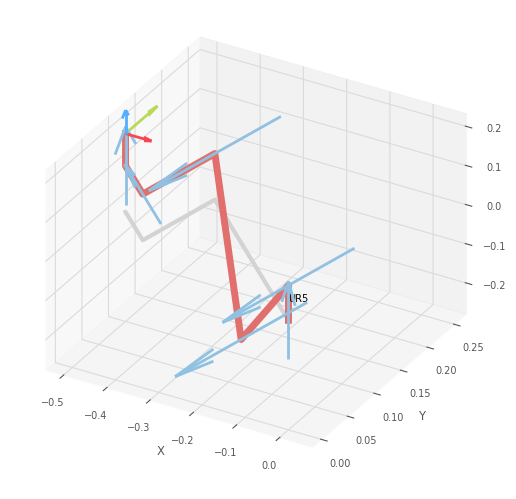

<Figure size 640x480 with 0 Axes>

In [ ]:
point = [-0.5,0.1,0.2]
T_end = sb.transl(point)
q_end = robot.ikine_GN(T_end).q  # Other methods available besides ikine_GN
robot.plot(q_end)
plt.show()

### 6. Plan the trajectory

Plan the trajectory using the 'jtraj' method for $N$ = 100 points

In [24]:
N = 100
t_start = 0
t_stop = 5
t_shag = t_stop/N
time = np.arange(t_start, t_stop, t_shag)

tr_jtraj = rtb.jtraj(q_start, q_end, time)

Plan the same trajectory using the 'mtraj' method with the 'trapezoidal' function

In [25]:
tr_trap = rtb.mtraj(rtb.trapezoidal, q_start, q_end, time)

Plan the same trajectory using the 'mtraj' method with the 'quintic' function

In [26]:
tr_quin = rtb.mtraj(rtb.quintic, q_start, q_end, time)

### 7. Plot graphs

Plot the position graphs for each link

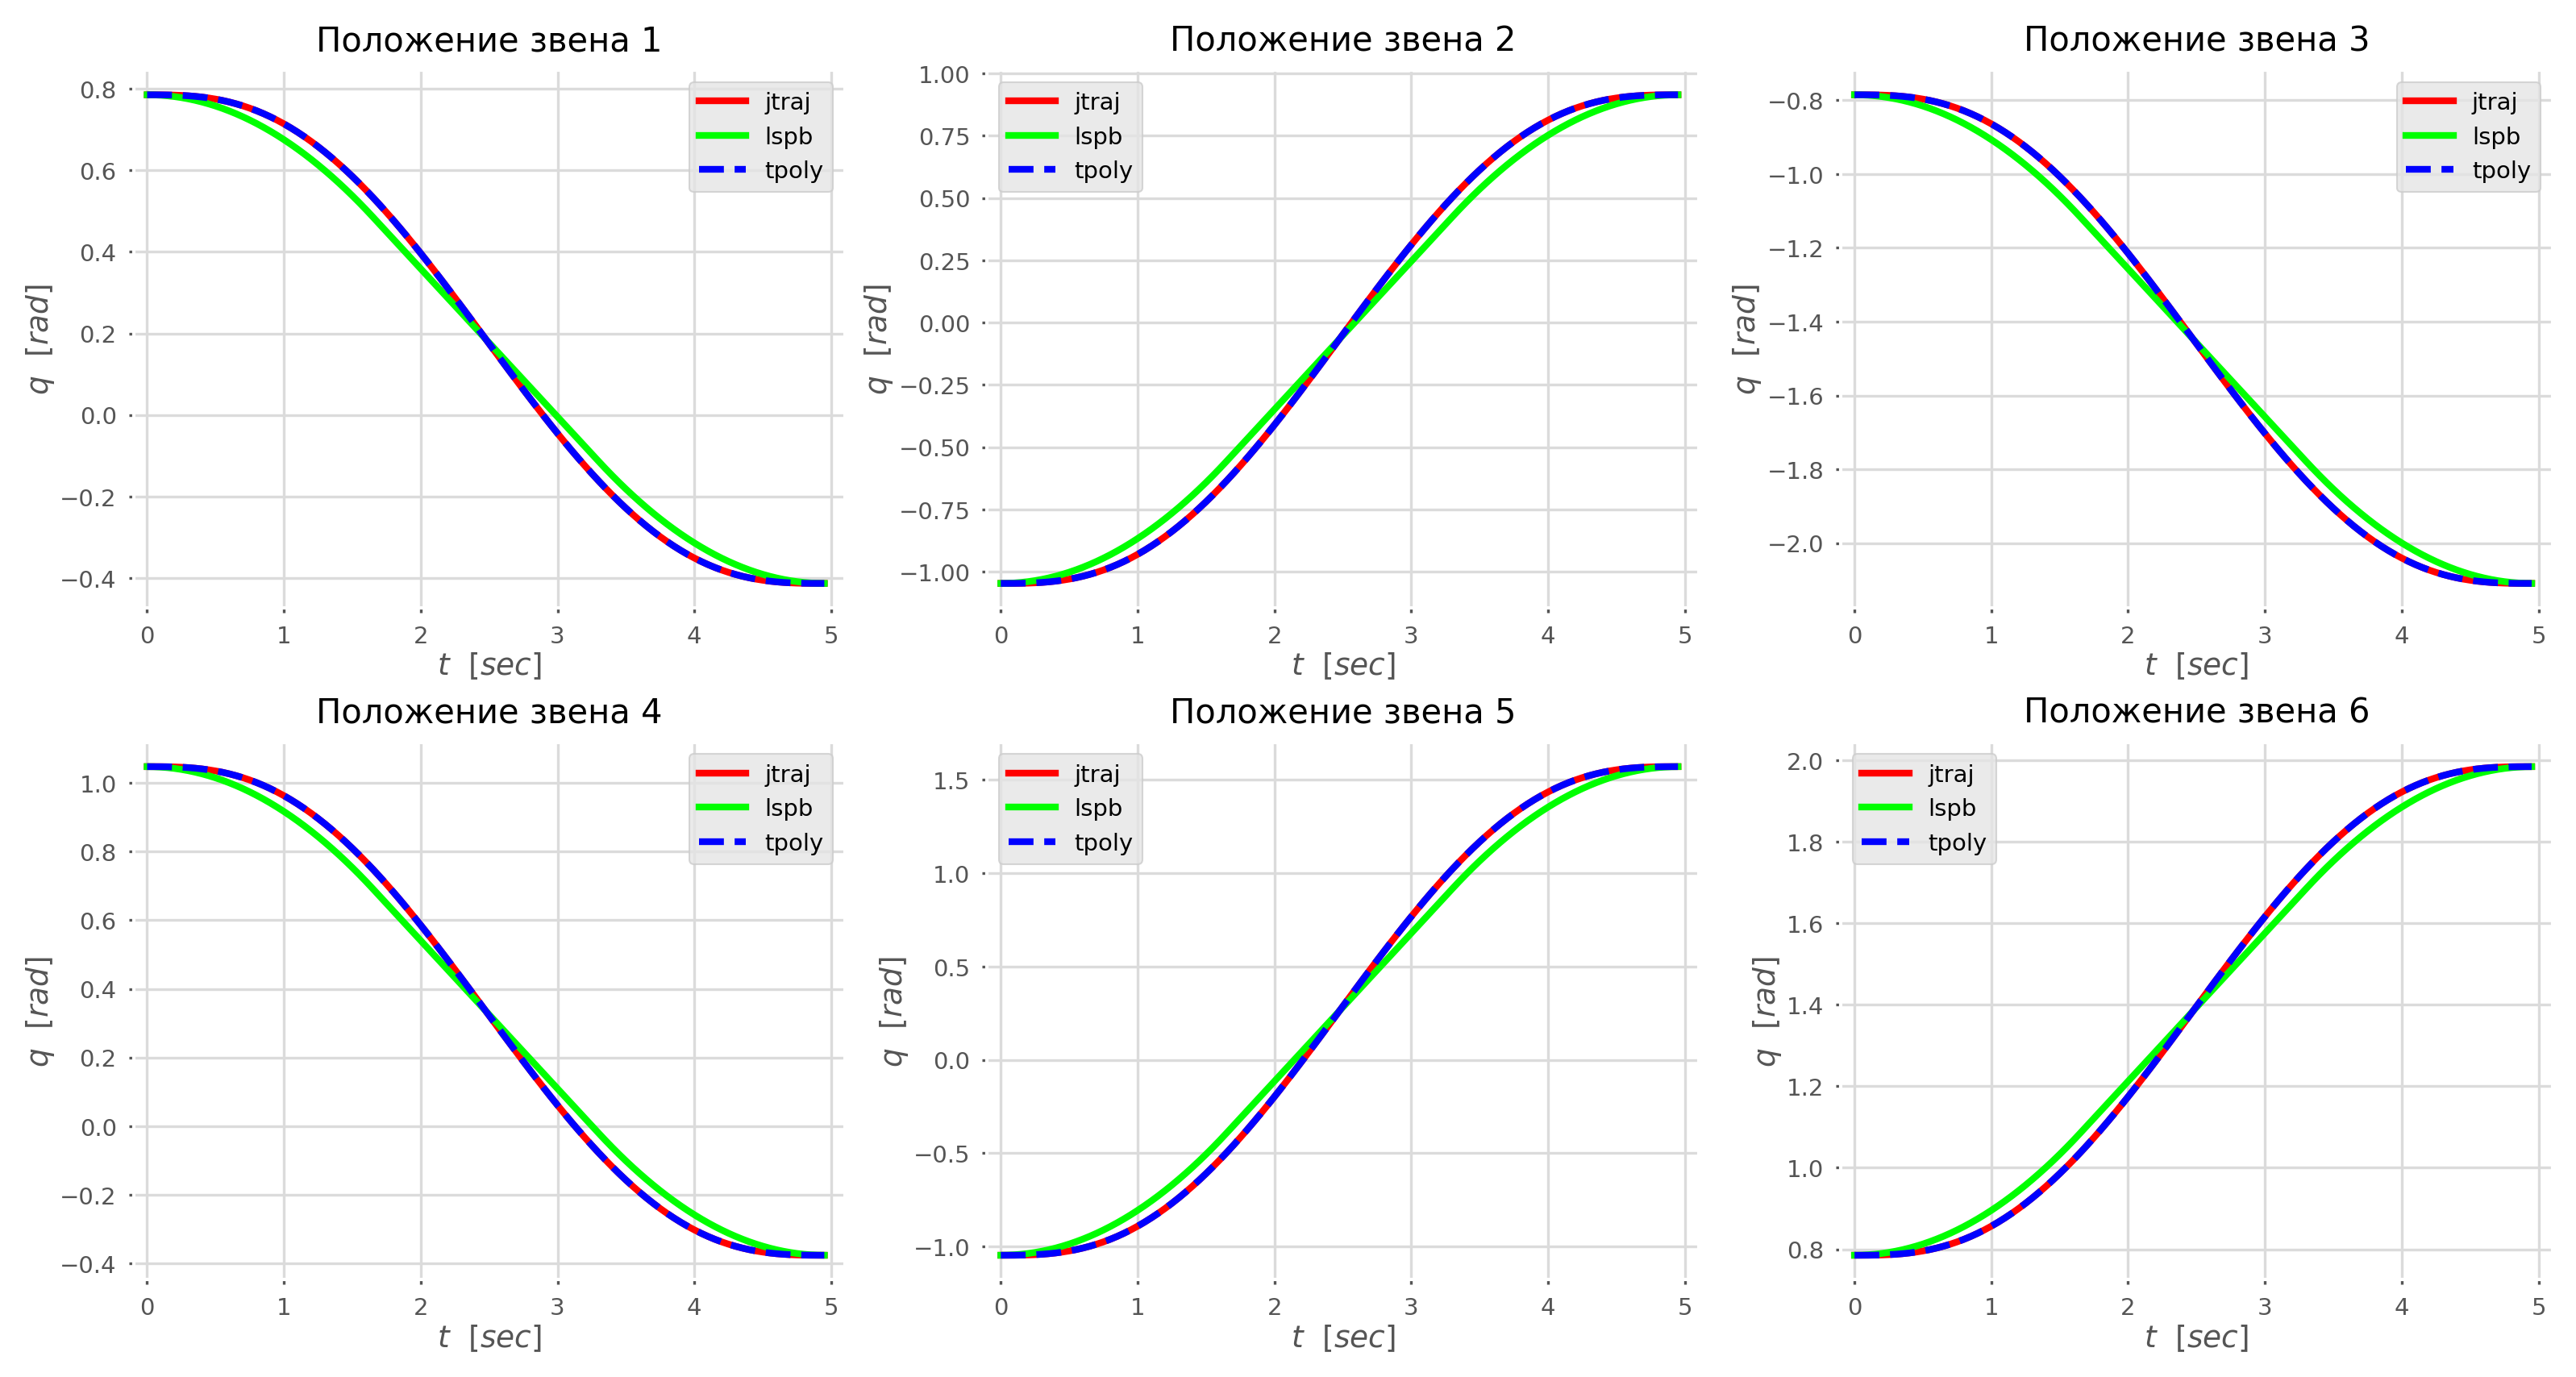

In [ ]:
plt.figure(figsize=(10,5), dpi=300)  # Set canvas size and DPI (graph clarity)
for g in range(1,7):
    plt.subplot(2,3,g)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.2, hspace=0.25)  # Set intervals to avoid overlapping
    traektoriya_jtraj = [tr_jtraj.q[i][g-1] for i in range(len(tr_jtraj.q))]  # Extract data
    traektoriya_trap = [tr_trap.q[i][g-1] for i in range(len(tr_trap.q))]  # Extract data
    traektoriya_quin = [tr_quin.q[i][g-1] for i in range(len(tr_quin.q))]  # Extract data
    plt.plot(time, traektoriya_jtraj, linestyle='-', linewidth=2, color=(1,0,0), label=r"jtraj")  # Draw line
    plt.plot(time, traektoriya_trap, linestyle='-', linewidth=2, color=(0,1,0), label=r"lspb")  # Draw line
    plt.plot(time, traektoriya_quin, linestyle='--', linewidth=2, color=(0,0,1), label=r"tpoly")  # Draw line
    plt.title(r"Position of link {}".format(g), fontsize=10)  # Graph title
    plt.ylabel(r"$q$  [$rad$]", fontsize=9)  # Y-axis label
    plt.xlabel(r"$t$  [$sec$]", fontsize=9)  # X-axis label
    plt.grid(True)  # Add grid
    plt.legend()  # Display legend (shows 'label')
    ax = plt.gca()  # gca = get current axis 
    ax.set_facecolor((1,1,1))  # Background color
    ax.set_xlim([t_start-0.1,t_stop+0.1])  # X-axis limits
plt.show()

Plot the velocity graphs for each link

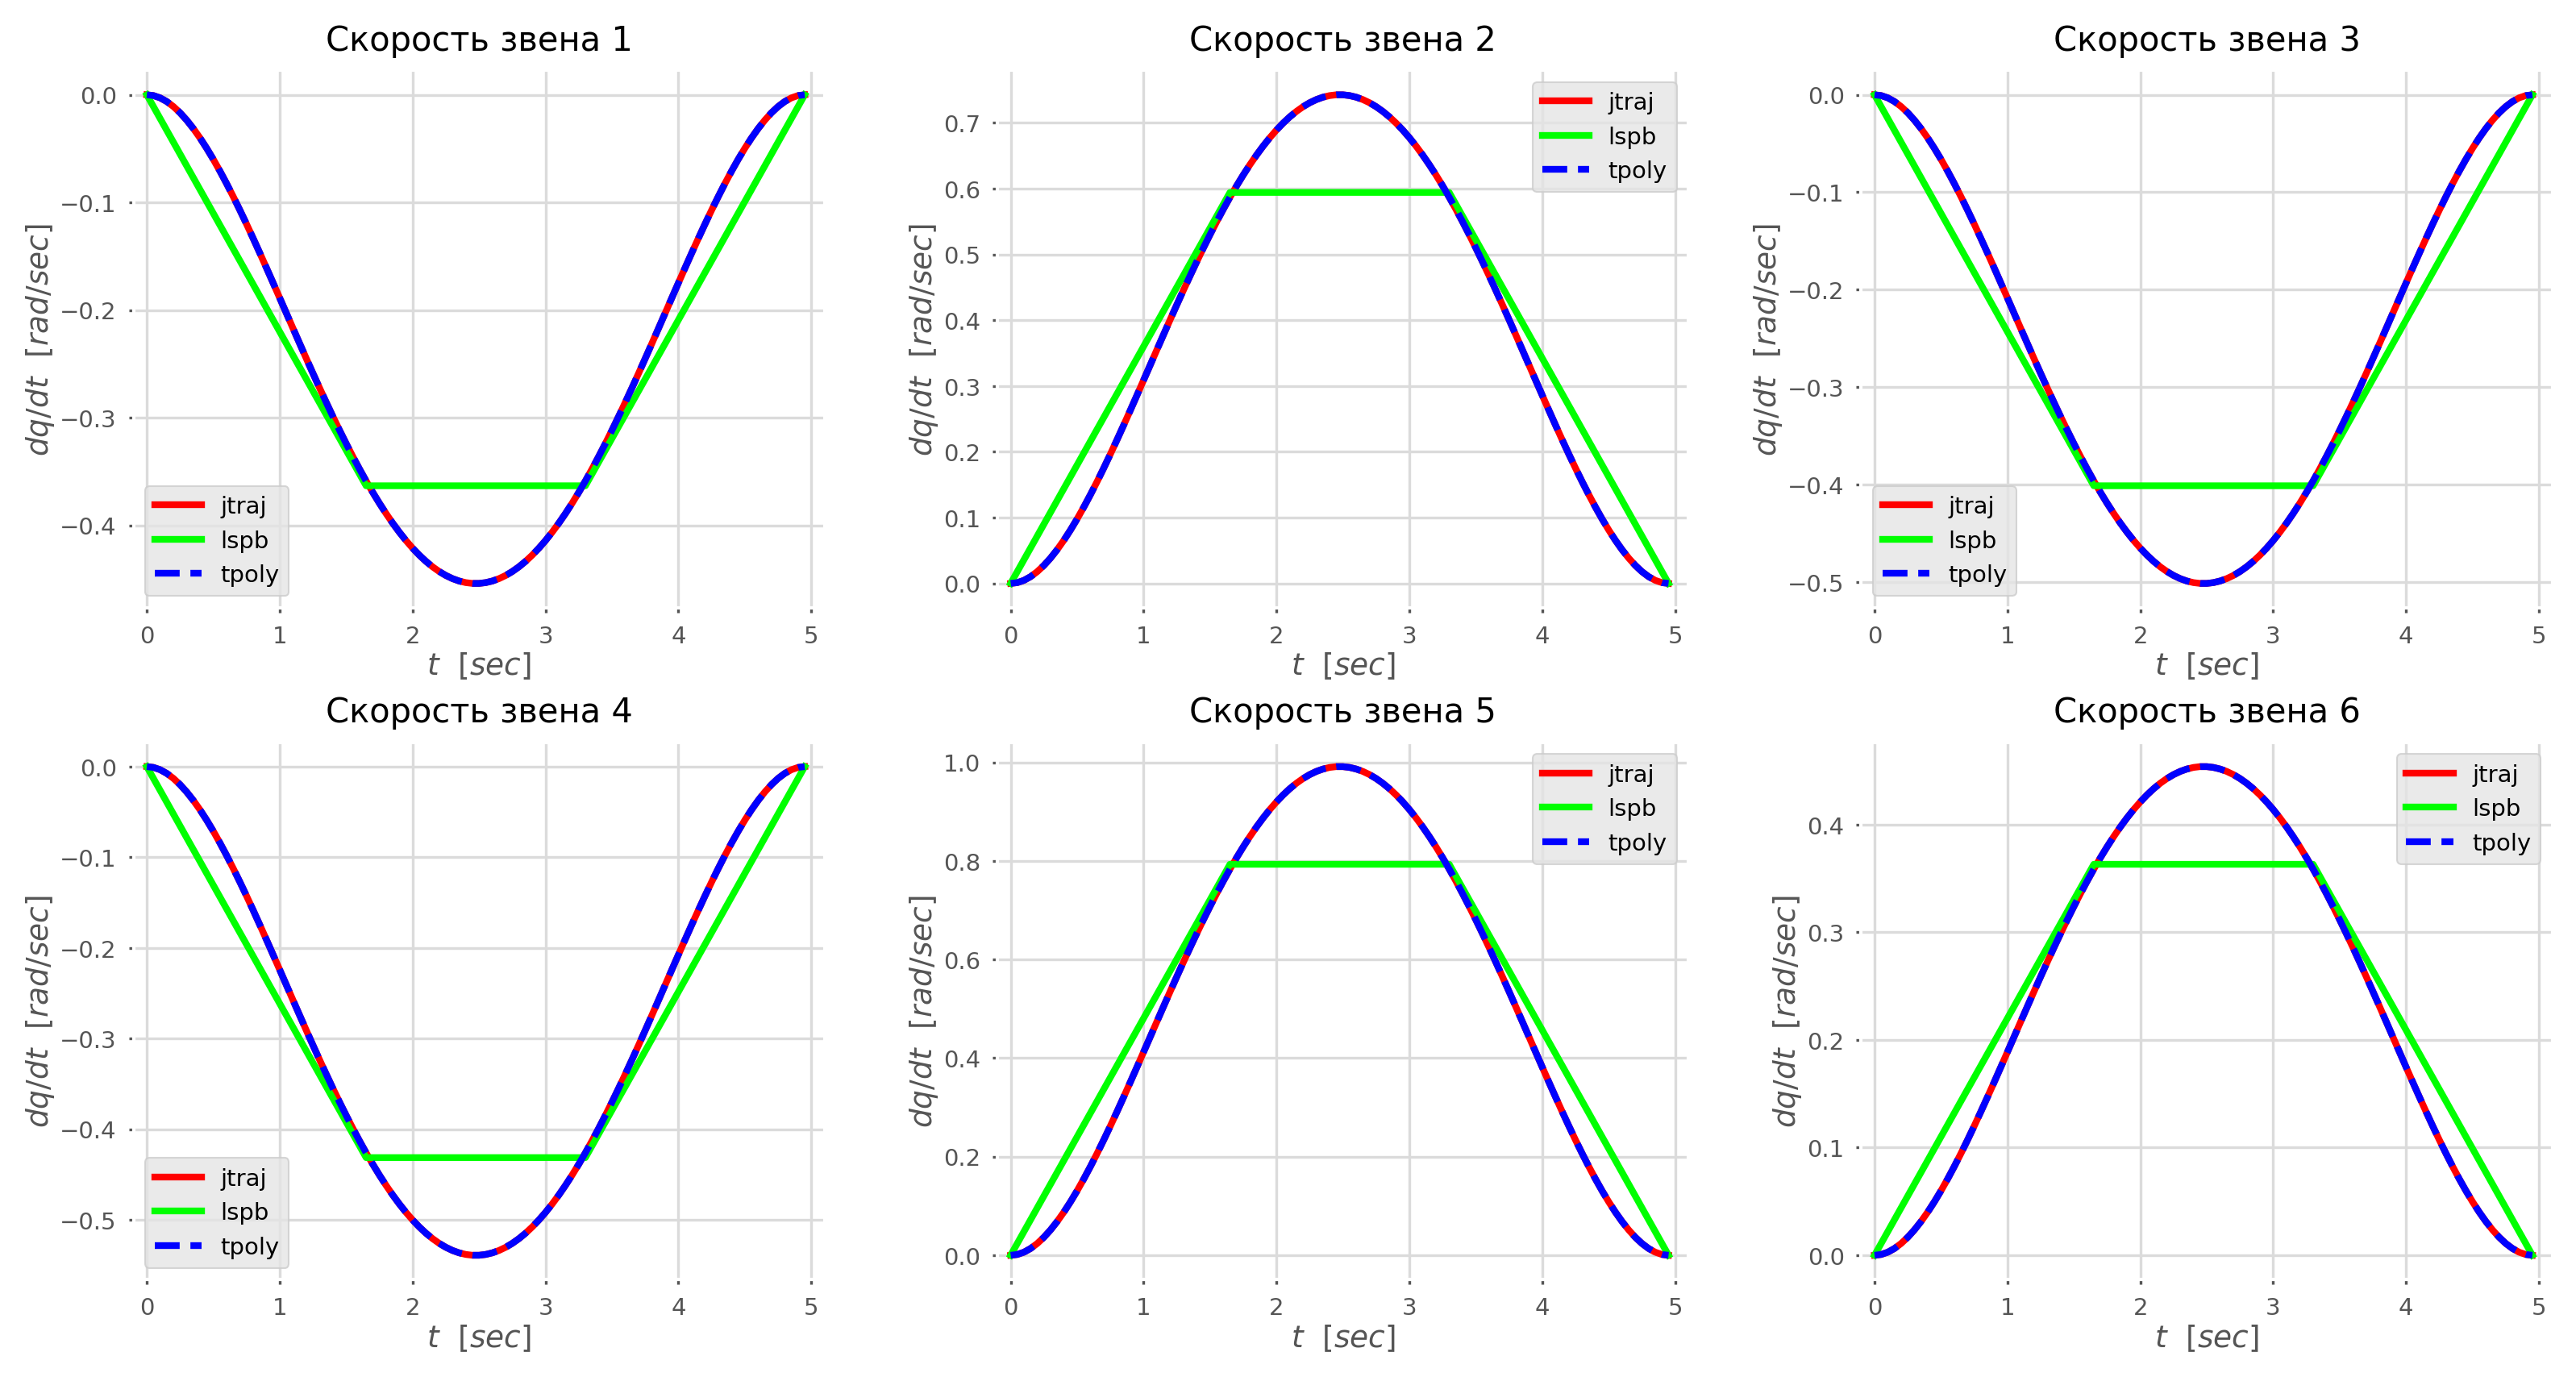

In [ ]:
plt.figure(figsize=(10,5), dpi=300)  # Set canvas size and DPI (graph clarity)
for g in range(1,7):
    plt.subplot(2,3,g)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.25, hspace=0.25)  # Set intervals to avoid overlapping
    traektoriya_jtraj = [tr_jtraj.qd[i][g-1] for i in range(len(tr_jtraj.qd))]  # Extract data
    traektoriya_trap = [tr_trap.qd[i][g-1] for i in range(len(tr_trap.qd))]  # Extract data
    traektoriya_quin = [tr_quin.qd[i][g-1] for i in range(len(tr_quin.qd))]  # Extract data
    plt.plot(time, traektoriya_jtraj, linestyle='-', linewidth=2, color=(1,0,0), label=r"jtraj")  # Draw line
    plt.plot(time, traektoriya_trap, linestyle='-', linewidth=2, color=(0,1,0), label=r"lspb")  # Draw line
    plt.plot(time, traektoriya_quin, linestyle='--', linewidth=2, color=(0,0,1), label=r"tpoly")  # Draw line
    plt.title(r"Velocity of link {}".format(g), fontsize=10)  # Graph title
    plt.ylabel(r"$dq/dt$  [$rad/sec$]", fontsize=9)  # Y-axis label
    plt.xlabel(r"$t$  [$sec$]", fontsize=9)  # X-axis label
    plt.grid(True)  # Add grid
    plt.legend()  # Display legend (shows 'label')
    ax = plt.gca()  # gca = get current axis
    ax.set_facecolor((1,1,1))  # Background color
    ax.set_xlim([t_start-0.1,t_stop+0.1])  # X-axis limits
plt.show()

Plot the acceleration graphs for each link

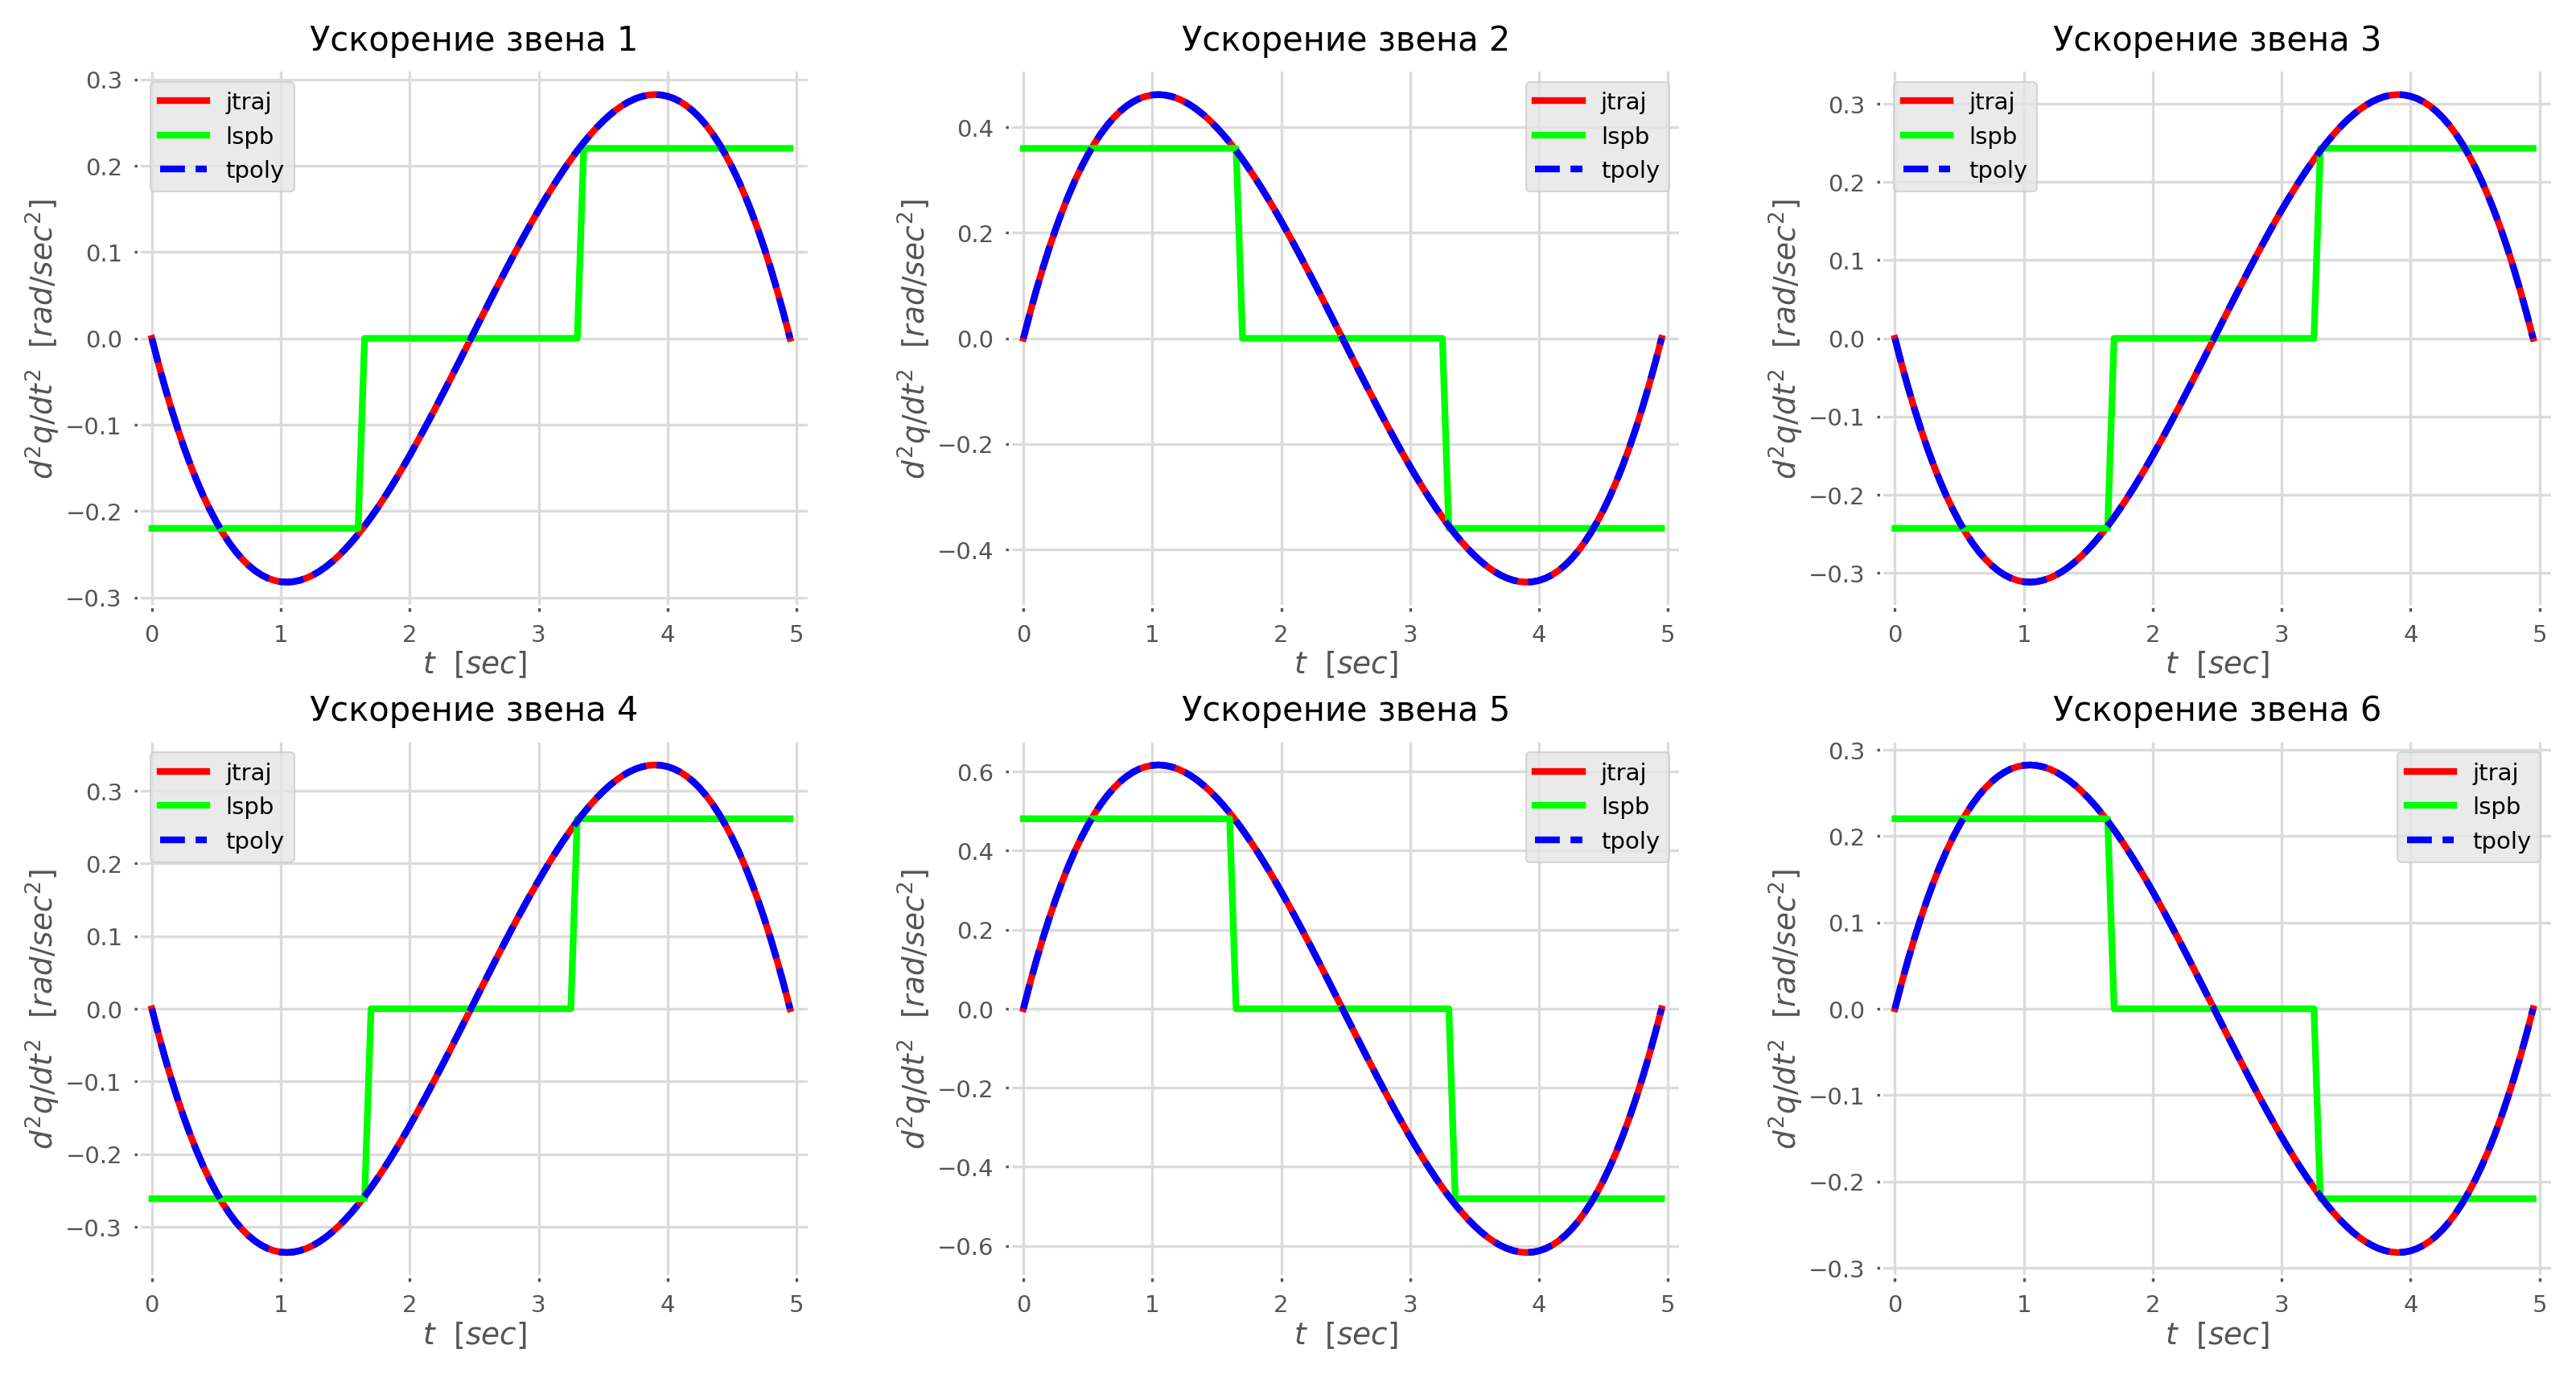

In [ ]:
fig = plt.figure(figsize=(10,5), dpi=300)  # Set canvas size and DPI (graph clarity)
for g in range(1,7):
    plt.subplot(2,3,g)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.3, hspace=0.25)  # Set intervals to avoid overlapping
    traektoriya_jtraj = [tr_jtraj.qdd[i][g-1] for i in range(len(tr_jtraj.qdd))]  # Extract data
    traektoriya_trap = [tr_trap.qdd[i][g-1] for i in range(len(tr_trap.qdd))]  # Extract data
    traektoriya_quin = [tr_quin.qdd[i][g-1] for i in range(len(tr_quin.qdd))]  # Extract data
    plt.plot(time, traektoriya_jtraj, linestyle='-', linewidth=2, color=(1,0,0), label=r"jtraj")  # Draw line
    plt.plot(time, traektoriya_trap, linestyle='-', linewidth=2, color=(0,1,0), label=r"lspb")  # Draw line
    plt.plot(time, traektoriya_quin, linestyle='--', linewidth=2, color=(0,0,1), label=r"tpoly")  # Draw line
    plt.title(r"Acceleration of link {}".format(g), fontsize=10)  # Graph title
    plt.ylabel(r"${d^2}q/d{t^2}$  [$rad/{sec}^2$]", fontsize=9)  # Y-axis label
    plt.xlabel(r"$t$  [$sec$]", fontsize=9)  # X-axis label
    plt.grid(True)  # Add grid
    plt.legend()  # Display legend (shows 'label')
    ax = plt.gca()  # gca = get current axis
    ax.set_facecolor((1,1,1))  # Background color
    ax.set_xlim([t_start-0.1,t_stop+0.1])  # X-axis limits
plt.show()

### 8. Conclusions
During the laboratory work, the kinematics of the manipulator were modeled and trajectory planning for its movement was conducted.
The forward and inverse kinematic problems were successfully solved, and the manipulator's workspace was determined.
The motion trajectories from the initial point to the final point were planned using three different methods (`jtraj`, `lspb` within `mtraj`, and `tpoly`/`quintic` within `mtraj`).

Analysis of the graphs shows:
- The **jtraj** method constructs a smooth trajectory in the joint space based on 5th-order polynomials, providing smooth changes in velocity and acceleration without jerk.
- The **lspb (Trapezoidal)** method provides linear acceleration, a section with constant velocity, and linear deceleration. However, acceleration has a step-like nature, which can cause undesirable vibrations in real mechanisms.
- The **quintic (tpoly)** method, similarly to jtraj, yields smooth profiles for position, velocity, and acceleration, making the movement more natural and safer for actuators.

As a result, we obtained a working environment for kinematic analysis and testing of trajectory control algorithms for a robotic manipulator.